In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import matplotlib.pyplot as plt


In [2]:
BASE_DIR = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset"


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [4]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [5]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Test"),
    transform=test_transform
)


In [6]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)


Classes: ['Fake', 'Real']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8096584..2.465708].


Image tensor shape: torch.Size([3, 224, 224])


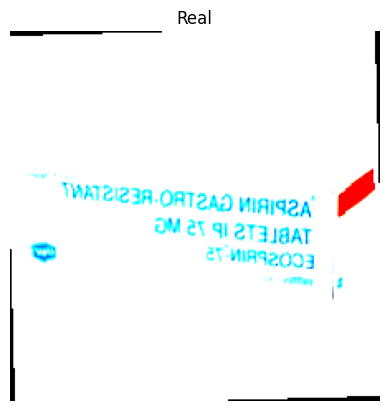

In [7]:
images, labels = next(iter(train_loader))

print("Image tensor shape:", images[0].shape)

plt.imshow(images[0].permute(1, 2, 0))
plt.title(train_dataset.classes[labels[0]])
plt.axis("off")
plt.show()
